## Initialisation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as lng
import pandas as pd
import scipy.stats as stats
import time
from numpy.linalg import norm
import os

In [2]:
# paramètres financiers

K = 100
T = 1
sigma = 0.3
r = 0.1

Smin = 50
Smax = 250
Sval = 90


I = 9
N = 10

dt = T/N


### Put

In [3]:
def phi_1(s):
    return np.maximum(K-s,0).reshape(len(s),1)

def vleft_1(t):
    return K - Smin

def vright_1(t):
    return 0

### Option Barrière

In [4]:
def phi_2(s):
    return ((K/2 <= s) & (s <= K)).reshape(-1, 1)
    
def vleft_2(t):
    return 0

def vright_2(t):
    return 0

## Algorithmes

In [5]:
def PSOR(B, b, g, x0, eta, kmax, I):
        x = x0.astype(float).copy()
        xold = np.full(x0.shape, np.inf, dtype=float)

        k = 0
        while (k < kmax) and (lng.norm(x - xold, np.inf) > eta):
            xold = x.copy()
            for i in range(I):
               x[i] = np.maximum((b[i] - sum(B[i,j]*x[j] for j in range(I) if j!=i))/B[i,i], g[i])
            k += 1
        return x

### Newton

In [6]:
def Newton(B, b, g, x0, eta, kmax):
    x = x0.astype(float).copy()
    xold = np.full(x0.shape, np.inf, dtype=float)
    k = 0

    def F_prime(B, b, g, x):
        condition = ((B@x - b) <= (x - g))[:,0]
        F_prime = np.identity(B.shape[0])
        F_prime[condition,:] = B[condition,:]
        return F_prime
    
    def F(B, b, g, x):
        return np.minimum(B@x-b,x-g)
    
    while (k < kmax) and (lng.norm(x - xold, np.inf) > eta):
        xold = x.copy()
        x = x - lng.solve(F_prime(B, b, g, x),F(B, b, g, x))
        k += 1
    return np.asarray(x)

### Décomposition UL

In [7]:
def ul_decomp(B):
    n = B.shape[0]
    U = np.identity(n)
    L = np.zeros_like(B)

    d_i = B[n-1,n-1]
    for i in range(n-1,0,-1):
        L[i,i-1] = B[i,i-1]
        U[i-1,i] = B[i-1,i]/d_i
        d_i = B[i-1,i-1] - U[i-1,i]*L[i,i-1]
        L[i-1,i-1] = d_i
        
    L[n-1,n-1] = B[n-1,n-1]
    return U, L

### Algorithme descente

In [8]:
def descente_p(L, b, g):
    n = L.shape[0]
    x = np.zeros(n)
    for i in range(n):
        x[i] = max(g[i, 0], (b[i, 0] - sum(L[i, j] * x[j] for j in range(i))) / L[i, i])
    return x.reshape(-1, 1)

### Brennan-Schwartz

In [9]:
def Brennan_Schwartz(U,B,b,g):
    d = {}
    upper, lower = ul_decomp(B=B)
    if lng.norm((B - upper@lower),np.inf) < 1e-7:
        c = lng.solve(upper, b).reshape(-1, 1)
        U = descente_p(L=lower, b=c, g=g)
    else:
        raise Exception("Décomposition UL non valide")
    d["err"] = lng.norm(np.minimum(B@U - b, U - g), np.inf)
    d["U"] = U
    return d

## Programme principale

In [10]:
def compute_price(SCHEME,I,N,u0,uleft,uright):
    dico = {}
    list_err = []
    Id = np.identity(I)

    h = (Smax-Smin)/(I+1)
    s = Smin + h*np.arange(1,I+1)
    alpha = (sigma**2)*0.5*((s**2)/(h**2))
    beta = r*(s/(2*h))
    
    A = np.zeros((I,I))
    L = np.arange(I-1)
    np.fill_diagonal(A,(2*alpha)+r)
    A[L,L+1] = (-alpha-beta)[:-1]
    A[L+1,L] = (-alpha+beta)[1:]

    def q(t):
        y = np.zeros((I,1))
        y[0] = (-alpha[0]+beta[0])*uleft(t)
        y[-1] = (-alpha[-1]-beta[-1])*uright(t)
        return y
      
    g = u0(s)
    U = g

    
    eta = 10**(-7)
    kmax = 1000

    for n in range(N):
        dt = T/N
        t = n*dt

        if SCHEME == 'EE-AMER':
            U = np.maximum((U - dt * (A@U + q(t))),g)
    
        if SCHEME == 'EI-AMER-SPLIT':
            b = U*(1/dt) - q(t+dt)
            A1 = A + Id*(1/dt)
            U = np.maximum(lng.solve(A1,b).reshape(I, 1),g)
    
        if SCHEME == 'CN-AMER-SPLIT':
            b = U*(1/dt) - 0.5*(A@U) - 0.5*(q(t)+q(t+dt))
            A1 = 0.5*A + Id*(1/dt)
            U = np.maximum(lng.solve(A1,b).reshape(I, 1),g)
    
        if SCHEME == 'EI-AMER-PSOR':
            b = U - dt*q(t+dt)
            B = Id + dt*A
            U = PSOR(B, b, g, U, eta, kmax,I)
    
        if SCHEME == 'EI-AMER-NEWTON':
            b = U - dt*q(t+dt)
            B = Id + dt*A
            U = Newton(B, b, g, U, eta, kmax)
    
        if SCHEME == 'EI-AMER-UL':
            B = Id + dt * A
            b = U - dt * q(t + dt)
            Compute_U = Brennan_Schwartz(U,B,b,g)
            U = Compute_U["U"]
            err = Compute_U["err"]
            list_err.append(err)
    
        if SCHEME == 'CN-AMER':
            B = Id + 0.5*dt * A
            b = (Id - 0.5*dt*A)@U - 0.5*dt*(q(t + dt) + q(t))
            U = Brennan_Schwartz(U,B,b,g)["U"]
            err = Brennan_Schwartz(U,B,b,g)["err"]
            list_err.append(err)
    
        if SCHEME == 'BDF-AMER':
            if n == 0:
                b = U - dt*q(t+dt)
                B = Id + dt*A
                U_prev = Newton(B, b, g, U, eta, kmax)
            
            else:
                B = 3/2*Id + dt * A
                upper, lower = ul_decomp(B=B)
                b = 2*U - 1/2*U_prev - dt*q(t + dt)

                if lng.norm((B - upper@lower),np.inf) < 1e-7:
                    c = lng.solve(upper, b).reshape(-1, 1)
                    U_prev = U
                    U = descente_p(L=lower, b=c, g=g)
                else:
                    raise Exception("Décomposition UL non valide")
                list_err.append(lng.norm(np.minimum(B@U - b, U - g), np.inf))


    def P_1_interpolated(Sval,s,U,I):
        i = np.argmax(s - Sval > 0) - 1
        return ((s[i+1]-Sval)/h)*U[i] + ((Sval-s[i])/h)*U[i+1]
        
    
    dico["h"] = h
    dico["s"] = s
    dico["A"] = A
    dico["U"] = U
    dico["u0"] = u0(s)
    dico["inter"] = P_1_interpolated(Sval,s,U,I)
    dico["list_error"] = list_err

    return dico

    

In [11]:
def conv_table(SCHEME, list_I, map_N,u0,uleft,uright):
    price_values, list_h, t_cpu, list_t = [], [], [], []
    for i, N in zip(list_I, map_N):
        dt = T/N
        t0 = time.time()
        res_i = compute_price(SCHEME, i, N,u0,uleft,uright)
        t1 = time.time()
        price_values.append(res_i["inter"][0])
        list_h.append(res_i["h"])
        list_t.append(dt)
        t_cpu.append(t1 - t0)

    conv_table = pd.DataFrame()
    conv_table["I"] = list_I
    conv_table["N"] = map_N
    conv_table["U(s)"] = price_values

    conv_table["error"] = np.abs(np.diff(price_values, prepend=np.nan))
    conv_table["alpha"] = np.diff(
        np.log(conv_table["error"]), prepend=np.nan
    ) / np.diff(np.log(np.array(list_h)), prepend=np.nan)
    conv_table["tcpu"] = t_cpu
    conv_table["beta"] = np.diff(
        np.log(conv_table["error"]), prepend=np.nan
    ) / np.diff(np.log(np.array(list_t)), prepend=np.nan)

    return conv_table

In [12]:
def plot(ax, SCHEME, I, N, u0, uleft, uright, title, payoff_label):
    Price = compute_price(SCHEME, I, N, u0, uleft, uright)
    s = Price["s"]
    U = Price["U"]
    u0 = Price["u0"]
    titre = "{}: I={}, N={}".format(title, I, N)

    ax.plot(s, U, label='Schéma')
    ax.plot(s, u0, label=payoff_label)
    ax.set_title(titre)
    ax.legend()

## Graphiques

### Euler Explicite

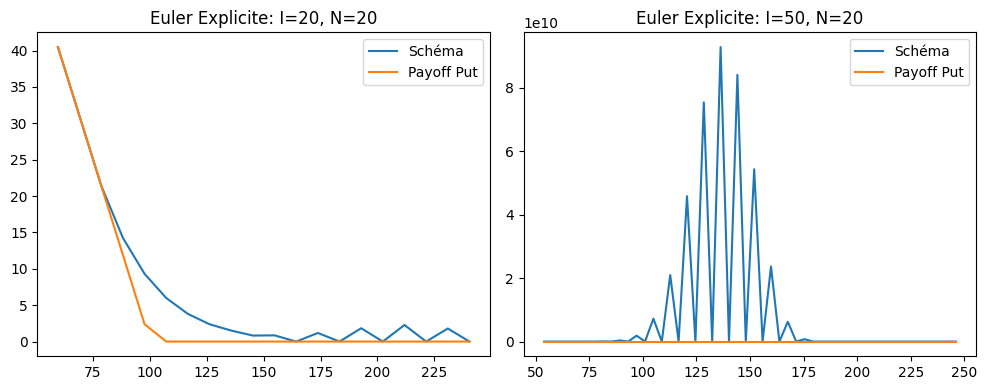

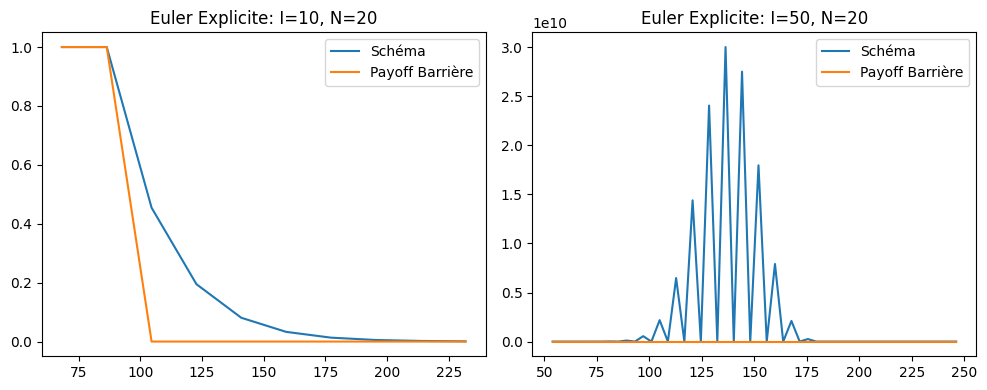

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plot(ax1, 'EE-AMER', 20, 20, phi_1, vleft_1, vright_1, 'Euler Explicite', 'Payoff Put')
plot(ax2, 'EE-AMER', 50, 20, phi_1, vleft_1, vright_1, 'Euler Explicite', 'Payoff Put')
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plot(ax1, 'EE-AMER', 10, 20, phi_2, vleft_2, vright_2, 'Euler Explicite', 'Payoff Barrière')
plot(ax2, 'EE-AMER', 50, 20, phi_2, vleft_2, vright_2, 'Euler Explicite', 'Payoff Barrière')
plt.tight_layout()
plt.show()

#### Convergence sous condition CFL

In [14]:
list_I = [(20 * 2**i)-1 for i in range(6)]
map_N = [2 * (i**2)//10 for i in list_I]
print("\033[1mEuler Explicite Put option\033[0m")
display(conv_table('EE-AMER',list_I,map_N,phi_1,vleft_1,vright_1))

Euler Explicite Put option


,I,N,U(s),error,alpha,tcpu,beta
0,19,72,12.948855,NaN,NaN,0.000000,NaN
1,39,304,13.064946,0.116091,NaN,0.002387,NaN
2,79,1248,13.109601,0.044655,1.378354,0.005001,0.676501
3,159,5056,13.117808,0.008207,2.443830,0.670229,1.210789
4,319,20352,13.119988,0.002179,1.913023,2.557515,0.952178
5,639,81664,13.120521,0.000533,2.031539,9.113803,1.013474


### Euler Implicit (SPLIT)

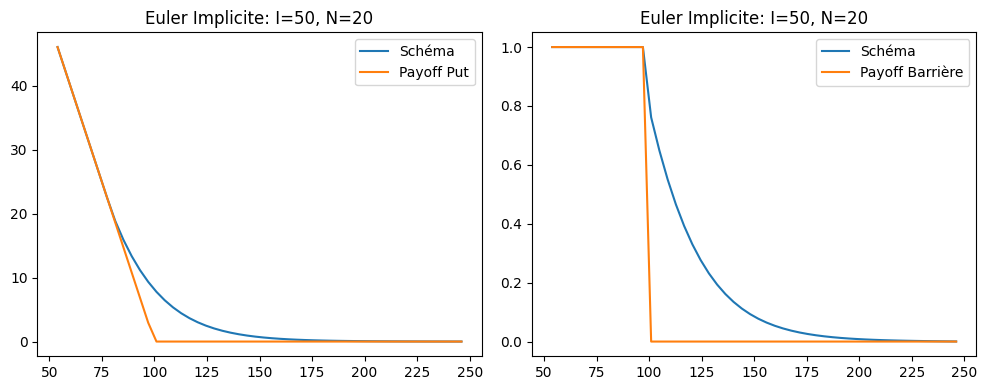

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plot(ax1, 'EI-AMER-SPLIT', 50, 20, phi_1, vleft_1, vright_1, 'Euler Implicite', 'Payoff Put')
plot(ax2, 'EI-AMER-SPLIT', 50, 20, phi_2, vleft_2, vright_2, 'Euler Implicite', 'Payoff Barrière')
plt.tight_layout()
plt.show()

#### Test numériques pour $(I + 1, N ) = (20, 20) ∗ 2^k, k = 0, 1, 2, 3, 4, ....$

In [16]:
list_I = [20 * 2**i for i in range(5)]
print("\033[1mEuler Implicite Put option\033[0m")
display(conv_table('EI-AMER-SPLIT',list_I,list_I,phi_1,vleft_1,vright_1))

Euler Implicite Put option


,I,N,U(s),error,alpha,tcpu,beta
0,20,20,13.009046,NaN,NaN,0.019087,NaN
1,40,40,13.027808,0.018763,NaN,0.260451,NaN
2,80,80,13.068309,0.040500,-1.130066,0.853931,-1.110061
3,160,160,13.093358,0.025050,0.699396,3.298620,0.693148
4,320,320,13.106508,0.013150,0.933928,14.436733,0.929737


### Cranck-Nicolson SPLIT

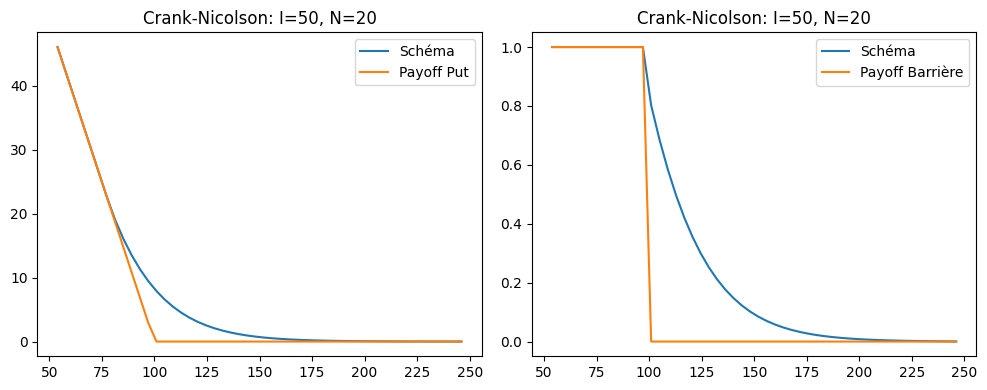

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plot(ax1, 'CN-AMER-SPLIT', 50, 20, phi_1, vleft_1, vright_1, 'Crank-Nicolson', 'Payoff Put')
plot(ax2, 'CN-AMER-SPLIT', 50, 20, phi_2, vleft_2, vright_2, 'Crank-Nicolson', 'Payoff Barrière')
plt.tight_layout()
plt.show()

#### Convergence table avec $(I + 1, N) = (20, 20) \cdot 2^k$ pour $\quad k = 0, 1, 2, 3, 4, \ldots$


In [18]:
list_I = [20 * 2**i for i in range(5)]
print("\033[1mCrank-Nicolson Put option\033[0m")
display(conv_table('CN-AMER-SPLIT',list_I,list_I,phi_1,vleft_1,vright_1))

Crank-Nicolson Put option


,I,N,U(s),error,alpha,tcpu,beta
0,20,20,13.136261,NaN,NaN,0.022531,NaN
1,40,40,13.085711,0.050551,NaN,0.340774,NaN
2,80,80,13.104917,0.019207,1.421266,0.821751,1.396107
3,160,160,13.111602,0.006685,1.536353,3.469223,1.522628
4,320,320,13.115865,0.004263,0.652081,14.619679,0.649155


### PSOR

On passe maintenant à l'analyse de la méthode de résolution explicite fournie par l'algorithme PSOR.


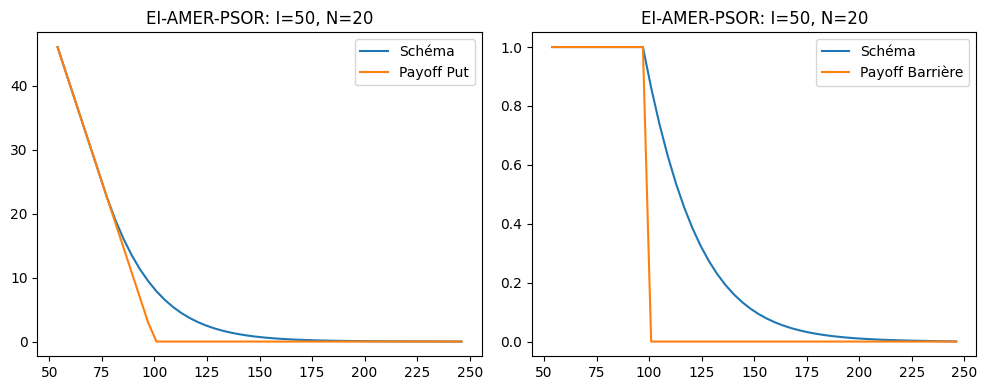

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plot(ax1, 'EI-AMER-PSOR', 50, 20, phi_1, vleft_1, vright_1, 'EI-AMER-PSOR', 'Payoff Put')
plot(ax2, 'EI-AMER-PSOR', 50, 20, phi_2, vleft_2, vright_2, 'EI-AMER-PSOR', 'Payoff Barrière')
plt.tight_layout()
plt.show()

### Newton semi-lisse (SSN)

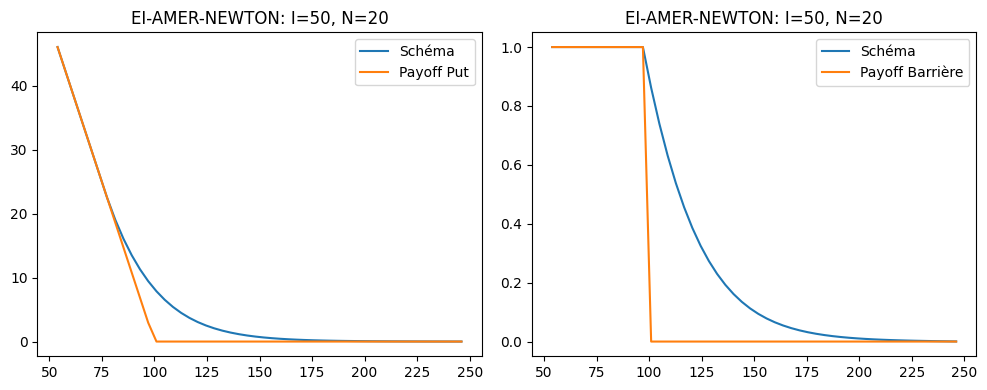

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plot(ax1, 'EI-AMER-NEWTON', 50, 20, phi_1, vleft_1, vright_1, 'EI-AMER-NEWTON', 'Payoff Put')
plot(ax2, 'EI-AMER-NEWTON', 50, 20, phi_2, vleft_2, vright_2, 'EI-AMER-NEWTON', 'Payoff Barrière')
plt.tight_layout()
plt.show()

#### Table $N = I$

In [21]:
list_I = [20 * 2**i for i in range(5)]
print("\033[1mNewton Algorithm Put option\033[0m")
display(conv_table('EI-AMER-NEWTON',list_I,list_I,phi_1,vleft_1,vright_1))

Newton Algorithm Put option


,I,N,U(s),error,alpha,tcpu,beta
0,20,20,13.137800,NaN,NaN,0.049038,NaN
1,40,40,13.084578,0.053221,NaN,0.305000,NaN
2,80,80,13.106557,0.021979,1.298869,1.470992,1.275877
3,160,160,13.111972,0.005414,2.039480,7.325773,2.021261
4,320,320,13.116142,0.004170,0.378387,30.585732,0.376689


#### Table $N = I/10$

### Brennan-Schwartz

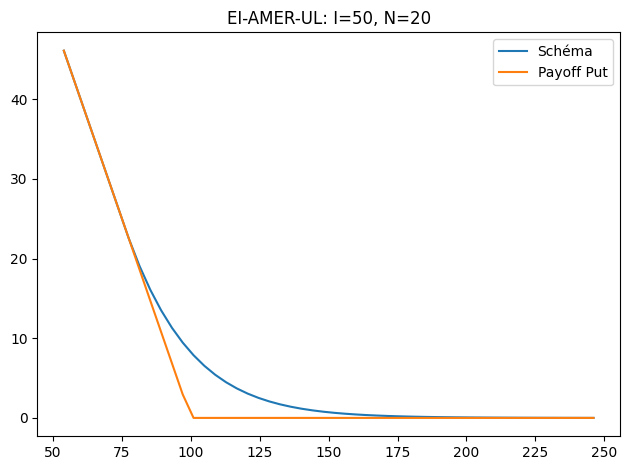

In [22]:
fig, (ax1) = plt.subplots(1)
plot(ax1, 'EI-AMER-UL', 50, 20, phi_1, vleft_1, vright_1, 'EI-AMER-UL', 'Payoff Put')
plt.tight_layout()
plt.show()

### Schémas d'ordre supérieur

#### Crank-Nicolson

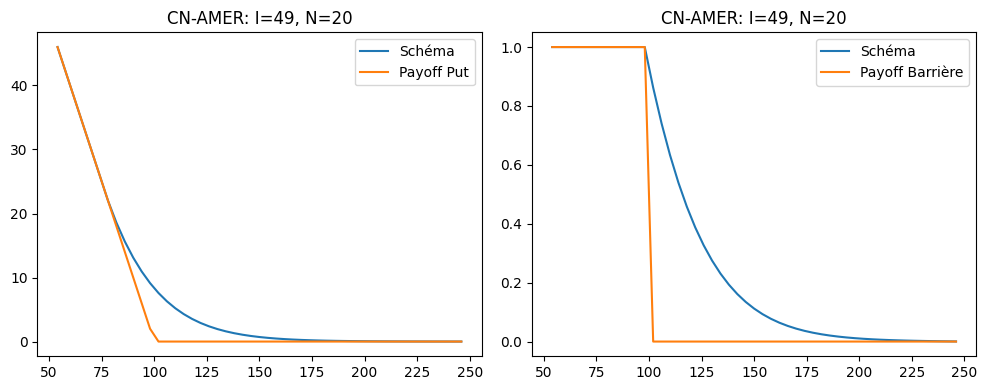

In [23]:
ig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plot(ax1, 'CN-AMER', 49, 20, phi_1, vleft_1, vright_1, 'CN-AMER', 'Payoff Put')
plot(ax2, 'CN-AMER', 49, 20, phi_2, vleft_2, vright_2, 'CN-AMER', 'Payoff Barrière')
plt.tight_layout()
plt.show()

In [25]:
list_I = [20 * 2**i for i in range(4)]
print("\033[1mCN-AMER Algorithm Put option\033[0m")
display(conv_table('CN-AMER',list_I,list_I,phi_1,vleft_1,vright_1))

CN-AMER Algorithm Put option


,I,N,U(s),error,alpha,tcpu,beta
0,20,20,13.197945,NaN,NaN,0.013334,NaN
1,40,40,13.115731,0.082214,NaN,0.292572,NaN
2,80,80,13.123969,0.008238,3.378917,2.028589,3.319104
3,160,160,13.120871,0.003098,1.423631,8.957983,1.410914


#### BDF

### $N=I/10$

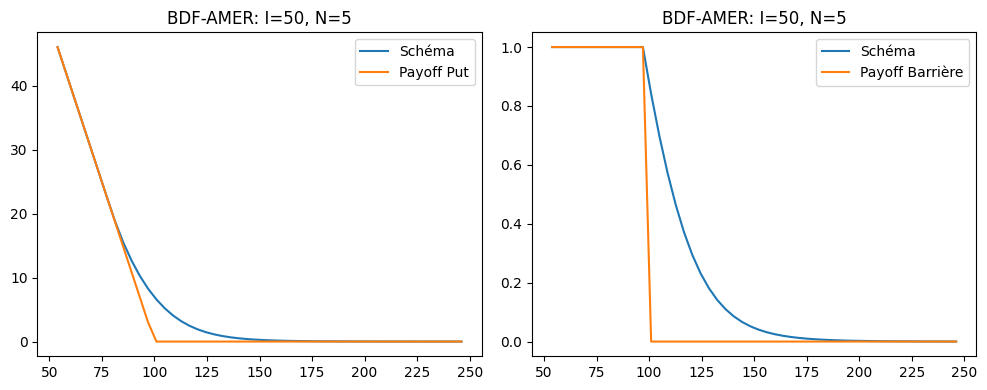

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plot(ax1, 'BDF-AMER', 50, 5, phi_1, vleft_1, vright_1, 'BDF-AMER', 'Payoff Put')
plot(ax2, 'BDF-AMER', 50, 5, phi_2, vleft_2, vright_2, 'BDF-AMER', 'Payoff Barrière')
plt.tight_layout()
plt.show()

### $N=I$

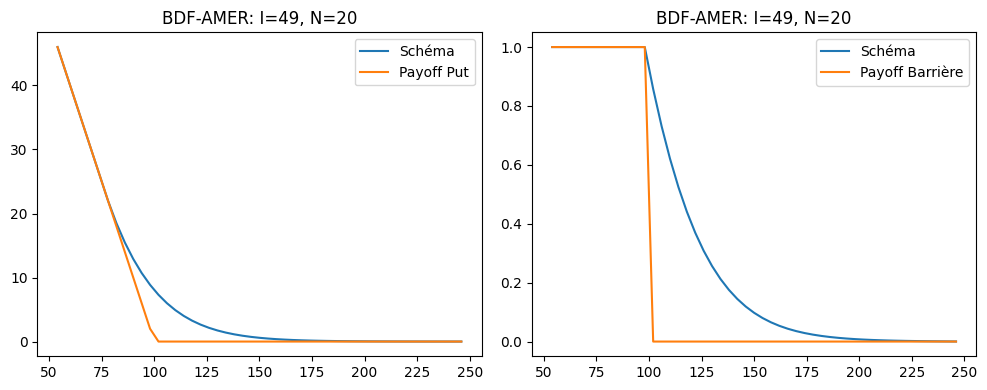

: 

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plot(ax1, 'BDF-AMER', 49, 20, phi_1, vleft_1, vright_1, 'BDF-AMER', 'Payoff Put')
plot(ax2, 'BDF-AMER', 49, 20, phi_2, vleft_2, vright_2, 'BDF-AMER', 'Payoff Barrière')
plt.tight_layout()
plt.show()


In [29]:
list_I = [20 * 2**i for i in range(6)]
print("\033[1mBDF-AMER Algorithm Put option\033[0m")
display(conv_table('BDF-AMER',list_I,list_I,phi_1,vleft_1,vright_1))

BDF-AMER Algorithm Put option


,I,N,U(s),error,alpha,tcpu,beta
0,20,20,13.001625,NaN,NaN,0.049416,NaN
1,40,40,13.018670,0.017045,NaN,0.285837,NaN
2,80,80,13.074872,0.056203,-1.752289,1.087583,-1.721270
3,160,160,13.096423,0.021551,1.395377,5.215189,1.382912
4,320,320,13.108544,0.012121,0.834012,26.428998,0.830269
5,640,640,13.114594,0.006051,1.004568,144.976325,1.002308
